# Классификация автомобилей с использованием Transfer Learning

**Цель:** добиться точности распознавания не ниже 93% на проверочной выборке.

**Подход:** transfer learning на базе предобученной модели MobileNetV2 из `tf.keras.applications`.

**База данных:** middle_fmr.zip (база автомобилей УИИ).

**Идея transfer learning:** взять модель, уже обученную на ImageNet (~1.4 млн изображений), и дообучить её последние слои под нашу задачу. Это даёт высокую точность на маленьких датасетах за короткое время обучения.

## Загрузка библиотек

In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import gdown

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     BatchNormalization, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Предобученная архитектура
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

## Загрузка датасета

In [2]:
# Загрузка zip-архива из облака УИИ
DATASET_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l5/middle_fmr.zip'
DATASET_ZIP = 'middle_fmr.zip'

gdown.download(DATASET_URL, DATASET_ZIP, quiet=False)

# Проверка, что файл скачался корректно
size_mb = os.path.getsize(DATASET_ZIP) / 1024 / 1024
print(f'\nРазмер скачанного архива: {size_mb:.1f} МБ')
assert size_mb > 1, 'Архив подозрительно маленький, проверьте URL!'

# Распаковка архива
!unzip -q -o "{DATASET_ZIP}" -d /content/cars

# Папка с папками-классами
IMAGE_PATH = '/content/cars'
print('\nСодержимое:', os.listdir(IMAGE_PATH))

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l5/middle_fmr.zip
To: /content/middle_fmr.zip
100%|██████████| 119M/119M [00:05<00:00, 20.4MB/s]



Размер скачанного архива: 113.5 МБ

Содержимое: ['Ferrari', 'Mercedes', 'Renault']


In [3]:
# Если внутри один уровень вложенности - корректируем путь
contents = os.listdir(IMAGE_PATH)
if len(contents) == 1 and os.path.isdir(os.path.join(IMAGE_PATH, contents[0])):
    IMAGE_PATH = os.path.join(IMAGE_PATH, contents[0])
    print(f'Путь скорректирован: {IMAGE_PATH}')

# Список классов
CLASS_LIST = sorted([d for d in os.listdir(IMAGE_PATH)
                     if os.path.isdir(os.path.join(IMAGE_PATH, d))])
CLASS_COUNT = len(CLASS_LIST)

print(f'\nКоличество классов: {CLASS_COUNT}')
print(f'Метки классов: {CLASS_LIST}')

# Размер каждого класса
print('\nРазмер каждого класса:')
for cls in CLASS_LIST:
    n = len(os.listdir(os.path.join(IMAGE_PATH, cls)))
    print(f'  {cls}: {n} фото')


Количество классов: 3
Метки классов: ['Ferrari', 'Mercedes', 'Renault']

Размер каждого класса:
  Ferrari: 1088 фото
  Mercedes: 1161 фото
  Renault: 1178 фото


## Гиперпараметры

In [4]:
# Параметры разделения
TEST_SPLIT      = 0.1
VAL_SPLIT       = 0.2

# Размер изображения - 224x224 стандарт для MobileNetV2
IMG_WIDTH       = 224
IMG_HEIGHT      = 224
IMG_CHANNELS    = 3

# Параметры обучения
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10    # Этап 1: обучаем только голову
EPOCHS_FINETUNE = 20    # Этап 2: fine-tuning

## Загрузка изображений

In [5]:
images = []
labels = []

for i, class_name in enumerate(CLASS_LIST):
    class_path = os.path.join(IMAGE_PATH, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            images.append(image.img_to_array(img))
            labels.append(i)
        except Exception as e:
            print(f'Пропущен {img_path}: {e}')

images = np.array(images, dtype='float32')
labels = np.array(labels)

print(f'Всего изображений: {len(images)}')
print(f'Форма массива: {images.shape}')
print(f'Распределение классов: {np.bincount(labels)}')

Всего изображений: 3427
Форма массива: (3427, 224, 224, 3)
Распределение классов: [1088 1161 1178]


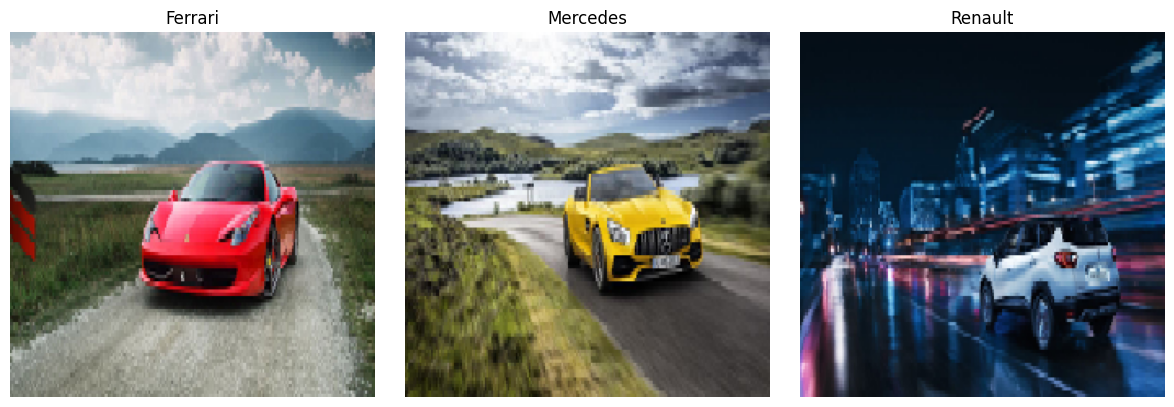

In [6]:
# Просмотр по одному изображению из каждого класса
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(4*CLASS_COUNT, 4))
if CLASS_COUNT == 1:
    axs = [axs]

for i in range(CLASS_COUNT):
    idx = np.where(labels == i)[0][0]
    axs[i].imshow(images[idx].astype('uint8'))
    axs[i].set_title(CLASS_LIST[i])
    axs[i].axis('off')
plt.tight_layout()
plt.show()

## Разделение на train / val / test со стратификацией

In [7]:
# Сначала отделяем тестовую выборку
x_train_full, x_test, y_train_full, y_test = train_test_split(
    images, labels,
    test_size=TEST_SPLIT,
    random_state=42,
    stratify=labels
)

# Затем делим на обучающую и проверочную
x_train, x_val, y_train_raw, y_val_raw = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT,
    random_state=42,
    stratify=y_train_full
)

# OHE
y_train = to_categorical(y_train_raw, num_classes=CLASS_COUNT)
y_val = to_categorical(y_val_raw, num_classes=CLASS_COUNT)
y_test_ohe = to_categorical(y_test, num_classes=CLASS_COUNT)

print(f'Обучающий набор:    {x_train.shape}')
print(f'Проверочный набор:  {x_val.shape}')
print(f'Тестовый набор:     {x_test.shape}')

Обучающий набор:    (2467, 224, 224, 3)
Проверочный набор:  (617, 224, 224, 3)
Тестовый набор:     (343, 224, 224, 3)


In [8]:
# Веса классов на случай дисбаланса
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Веса классов: {class_weight_dict}')

Веса классов: {0: np.float64(1.0502341421881651), 1: np.float64(0.983652312599681), 2: np.float64(0.9697327044025157)}


## Аугментация и подготовка данных

**Важно:** для предобученных моделей вместо стандартной нормализации `1/255` используется `preprocess_input` из `tf.keras.applications.mobilenet_v2`. Эта функция приводит данные к диапазону [-1, 1], в котором обучалась MobileNetV2.

In [9]:
# Генератор для обучения - аугментация + нормализация под MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Для val и test - только нормализация
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
validation_generator = val_datagen.flow(x_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_generator = test_datagen.flow(x_test, y_test_ohe, batch_size=BATCH_SIZE, shuffle=False)

## Создание модели на базе MobileNetV2

**Архитектура:**
1. **MobileNetV2** — предобученная база, без classification-головы
2. **GlobalAveragePooling2D** — преобразует карту признаков в вектор
3. **Dense + Dropout** — новая голова под нашу задачу
4. **Выходной Dense с softmax** — по числу классов

In [10]:
# Загружаем MobileNetV2 без верхнего слоя
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,
    weights='imagenet',
    pooling=None
)

# ЭТАП 1: замораживаем базу
base_model.trainable = False

# Собираем модель
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(CLASS_COUNT, activation='softmax')(x)

model = Model(inputs, outputs)

print(f'Всего параметров:        {model.count_params():,}')
print(f'Обучаемых параметров:    {sum(tf.size(w).numpy() for w in model.trainable_weights):,}')
print(f'Замороженных параметров: {sum(tf.size(w).numpy() for w in model.non_trainable_weights):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Всего параметров:        2,427,971
Обучаемых параметров:    167,171
Замороженных параметров: 2,260,800


## Этап 1: обучение головы (база заморожена)

С замороженной базой можем использовать высокий learning rate — обучаются только новые слои.

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-5, verbose=1)
]

history_stage1 = model.fit(
    train_generator,
    epochs=EPOCHS_FROZEN,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1,
    verbose=1
)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 91s 890ms/step - accuracy: 0.6627 - loss: 0.9128 - val_accuracy: 0.8023 - val_loss: 0.4684 - learning_rate: 0.0010
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 36s 459ms/step - accuracy: 0.7685 - loss: 0.6158 - val_accuracy: 0.8006 - val_loss: 0.4390 - learning_rate: 0.0010
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 435ms/step - accuracy: 0.7831 - loss: 0.5517 - val_accuracy: 0.8136 - val_loss: 0.4393 - learning_rate: 0.0010
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 406ms/step - accuracy: 0.8058 - loss: 0.4939 - val_accuracy: 0.8233 - val_loss: 0.4135 - learning_rate: 0.0010
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 424ms/step - accuracy: 0.8018 - loss: 0.4843 - val_accuracy: 0.8088 - val_loss: 0.4484 - learning_rate: 0.0010
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8077 - loss: 0.4736
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
78/78 ━━━━━━━━━━━━━━━━━━━━ 31s 400ms/step - accuracy: 0.8156 - loss: 0.44

## Этап 2: Fine-tuning (размораживаем верхние слои базы)

Размораживаем верхнюю часть MobileNetV2 и дообучаем всю модель с очень маленьким learning rate. Это позволяет модели адаптировать высокоуровневые признаки под автомобили, не разрушая полезные низкоуровневые признаки.

In [12]:
# Размораживаем базу
base_model.trainable = True

# Замораживаем нижние слои - учим только верхние ~30%
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Перекомпиляция с очень маленьким learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Обучаемых параметров на этапе 2: {trainable_params:,}')

Обучаемых параметров на этапе 2: 2,028,611


In [13]:
callbacks_stage2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
]

history_stage2 = model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 78s 689ms/step - accuracy: 0.7471 - loss: 0.6327 - val_accuracy: 0.8282 - val_loss: 0.3980 - learning_rate: 1.0000e-05
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 405ms/step - accuracy: 0.7783 - loss: 0.5441 - val_accuracy: 0.8104 - val_loss: 0.4581 - learning_rate: 1.0000e-05
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 423ms/step - accuracy: 0.8139 - loss: 0.4750 - val_accuracy: 0.8055 - val_loss: 0.4909 - learning_rate: 1.0000e-05
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.8086 - loss: 0.4722
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 531ms/step - accuracy: 0.8079 - loss: 0.4767 - val_accuracy: 0.8169 - val_loss: 0.4760 - learning_rate: 1.0000e-05
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 427ms/step - accuracy: 0.8204 - loss: 0.4483 - val_accuracy: 0.8201 - val_loss: 0.4580 - learning_rate: 3.0000e-06
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 404ms/step - accuracy

## График обучения

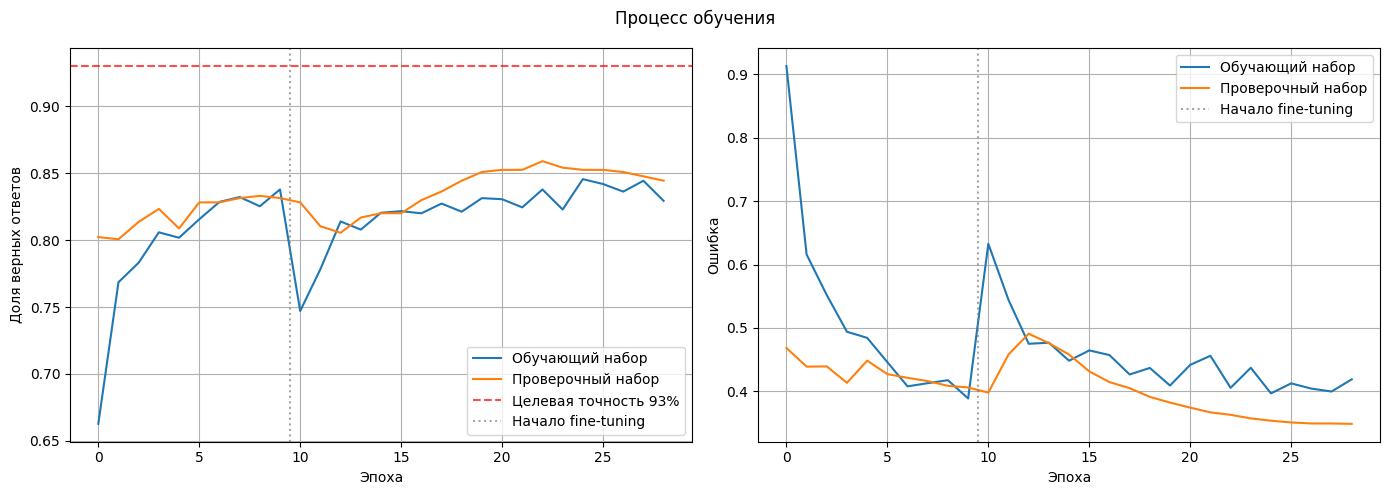


Лучшая точность на проверочной выборке: 0.8590 (85.90%)
Цель пока не достигнута


In [14]:
# Объединяем историю обоих этапов
acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
loss = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

stage1_end = len(history_stage1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Процесс обучения')

ax1.plot(acc, label='Обучающий набор')
ax1.plot(val_acc, label='Проверочный набор')
ax1.axhline(y=0.93, color='r', linestyle='--', alpha=0.7, label='Целевая точность 93%')
ax1.axvline(x=stage1_end - 0.5, color='gray', linestyle=':', alpha=0.7, label='Начало fine-tuning')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Доля верных ответов')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Обучающий набор')
ax2.plot(val_loss, label='Проверочный набор')
ax2.axvline(x=stage1_end - 0.5, color='gray', linestyle=':', alpha=0.7, label='Начало fine-tuning')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Ошибка')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

best_val_acc = max(val_acc)
print(f'\nЛучшая точность на проверочной выборке: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
if best_val_acc >= 0.93:
    print('Цель достигнута! Точность не ниже 93%')
else:
    print('Цель пока не достигнута')

## Оценка на тестовой выборке

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


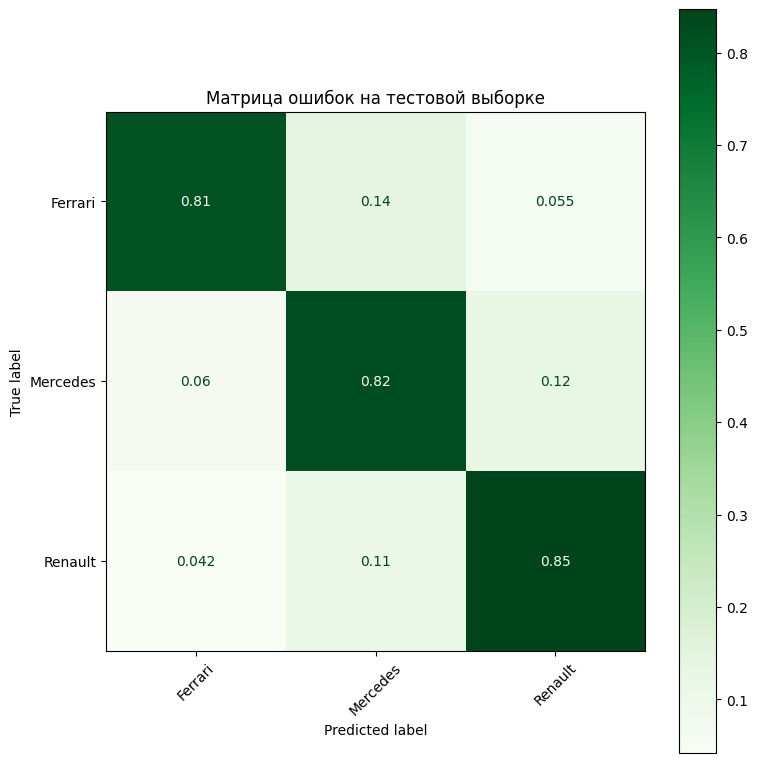


Подробный отчёт по классам:
              precision    recall  f1-score   support

     Ferrari       0.88      0.81      0.84       109
    Mercedes       0.77      0.82      0.79       116
     Renault       0.83      0.85      0.84       118

    accuracy                           0.83       343
   macro avg       0.83      0.82      0.83       343
weighted avg       0.83      0.83      0.83       343



In [18]:
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred_classes, normalize='true')
cm = np.round(cm, 3)

fig, ax = plt.subplots(figsize=(max(8, CLASS_COUNT), max(8, CLASS_COUNT)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(ax=ax, cmap='Greens', colorbar=True, xticks_rotation=45)
plt.title('Матрица ошибок на тестовой выборке')
plt.tight_layout()
plt.show()

print('\nПодробный отчёт по классам:')
print(classification_report(y_true, y_pred_classes, target_names=CLASS_LIST))

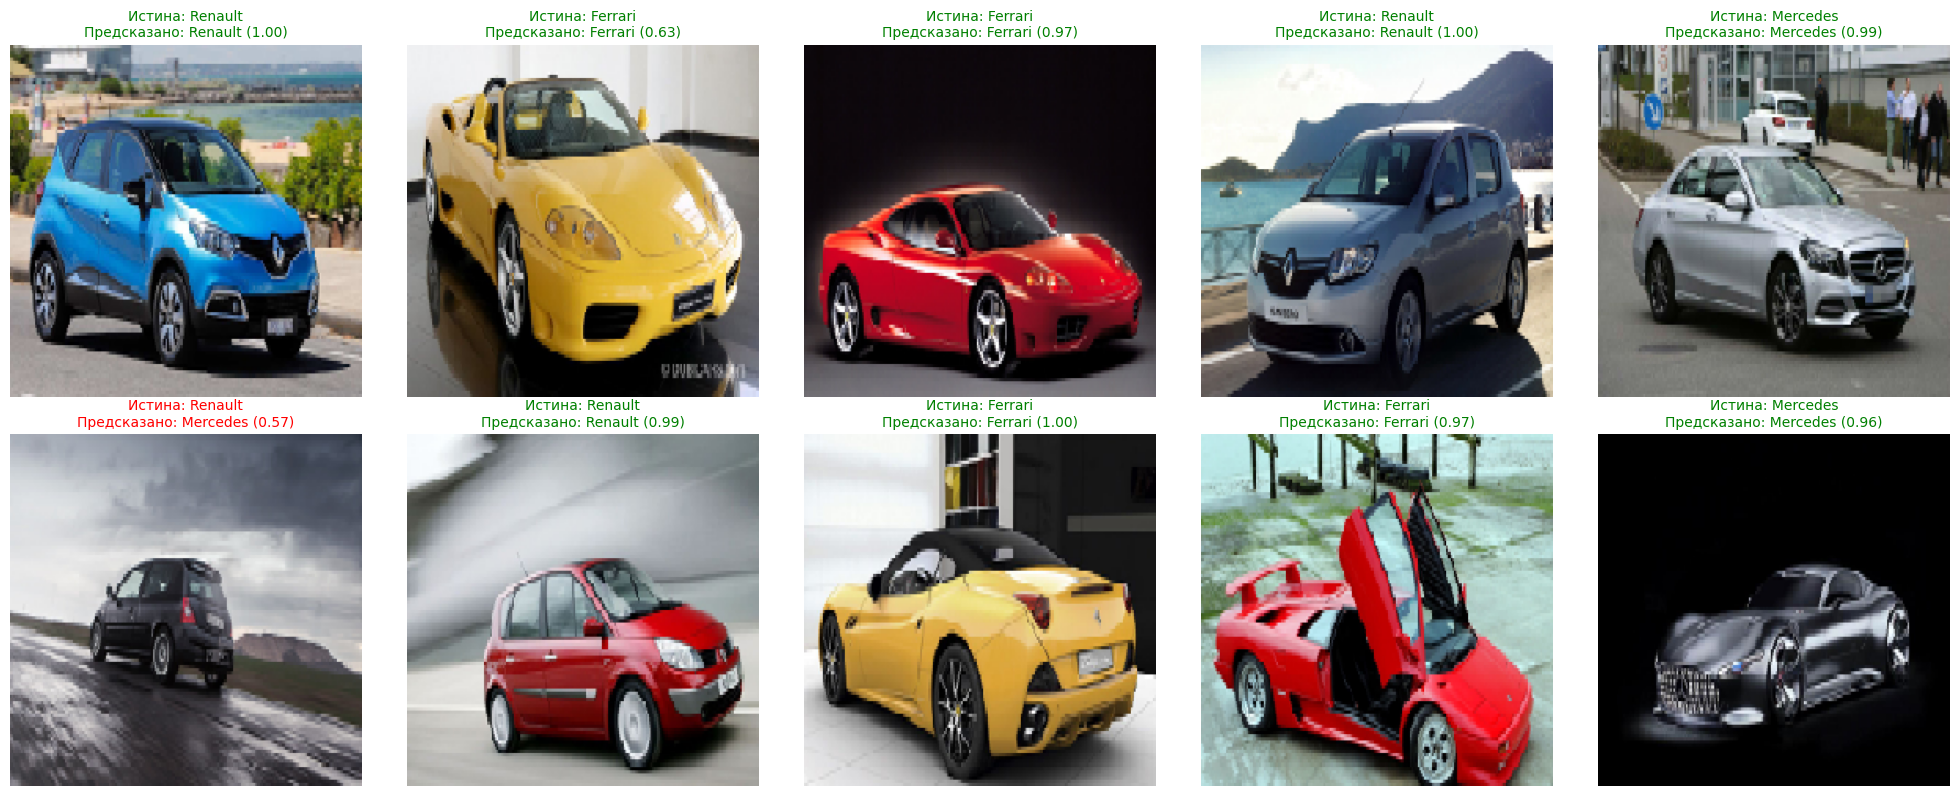

In [16]:
# Просмотр предсказаний на случайных примерах
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()

indices = random.sample(range(len(x_test)), 10)
for i, idx in enumerate(indices):
    img = x_test[idx].astype('uint8')
    true_label = CLASS_LIST[y_test[idx]]
    pred_label = CLASS_LIST[y_pred_classes[idx]]
    pred_proba = y_pred[idx][y_pred_classes[idx]]

    color = 'green' if true_label == pred_label else 'red'
    axs[i].imshow(img)
    axs[i].set_title(f'Истина: {true_label}\nПредсказано: {pred_label} ({pred_proba:.2f})',
                     color=color, fontsize=10)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Сохранение модели
model.save('cars_mobilenetv2.keras')
print('Модель сохранена в cars_mobilenetv2.keras')

Модель сохранена в cars_mobilenetv2.keras
